## Implement simple and multilinear regression model 

In [2]:
# import Requirment libraries
import pandas as pd
import numpy as np  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load the dataset
data = pd.read_csv(r"C:\data-Scientist\sample_experience_salary_age.csv")
df = pd.DataFrame(data)
df.head()

,experience,salary,age
0,6,493231,31
1,19,902168,40
2,14,923544,36
3,10,634020,28
4,7,557552,26


In [5]:
# simple linear regression
X = df[['experience']]
y = df['salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train) 
y_pred = model.predict(X_test)

print("simple linear regression results:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))


simple linear regression results:
Mean Squared Error: 131479228448.195
R^2 Score: 0.32796870800977884


In [6]:
# Save the model
with open('simple_linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)   
# Load the model
with open('simple_linear_regression_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
sample_data = [[5]]  # Example input for prediction
print("Prediction for sample data (experience = 5):", loaded_model.predict(sample_data)[0])

Prediction for sample data (experience = 5): 200000


In [7]:
# multiple linear regression
X_multi = df[['experience', 'age']]
y_multi = df['salary']  
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
model_multi = LogisticRegression()  
model_multi.fit(X_train_multi, y_train_multi)
y_pred_multi = model_multi.predict(X_test_multi)
print("\nMultiple linear regression results:")
print("Mean Squared Error:", mean_squared_error(y_test_multi, y_pred_multi))
print("R^2 Score:", r2_score(y_test_multi, y_pred_multi))



Multiple linear regression results:
Mean Squared Error: 80134652571.04
R^2 Score: 0.5904068290017196


In [8]:
# save the model
with open('model.pkl', 'wb') as file:
    pickle.dump(model_multi, file)
# Load the model
with open('model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
# Predict using the loaded model
sample_data_multi = [[5, 34]]  # Example input for prediction
print("Prediction for sample data (experience = 5, age = 34):", loaded_model.predict(sample_data_multi)[0])


Prediction for sample data (experience = 5, age = 34): 219956


## Build a logistic Regression model : evaluate it using confusion matrix,ROC & AUC

In [11]:
# import requirement libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# create a sample dataset
import pandas as pd
import numpy as np

# Reproducible randomness
np.random.seed(42)

# Generate hours studied (0 to 10 hours/day)
hours_studied = np.round(np.random.normal(loc=4, scale=2, size=1000), 1)
hours_studied = np.clip(hours_studied, 0, 10)

# Generate attendance percentage (50% to 100%)
attendance = np.round(np.random.normal(loc=80, scale=10, size=1000), 1)
attendance = np.clip(attendance, 50, 100)

# Probability of passing based on weighted sum (simple logic)
prob_pass = (0.05 * hours_studied + 0.01 * attendance)
prob_pass = np.clip(prob_pass, 0, 1)
pass_exam = np.random.binomial(n=1, p=prob_pass)

# Create DataFrame
df = pd.DataFrame({
    'hours_studied': hours_studied,
    'attendance': attendance,
    'pass': pass_exam
})

# Export to CSV (optional)
df.to_csv('student_performance.csv', index=False)
print("Student performance CSV generated!")


Student performance CSV generated!


In [13]:
# Load the dataset
data_1=pd.read_csv(r"C:\data-Scientist\stu.csv")
df= pd.DataFrame(data_1)

In [14]:
x=df[['hours_studied', 'attendance']]
y=df['pass']

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

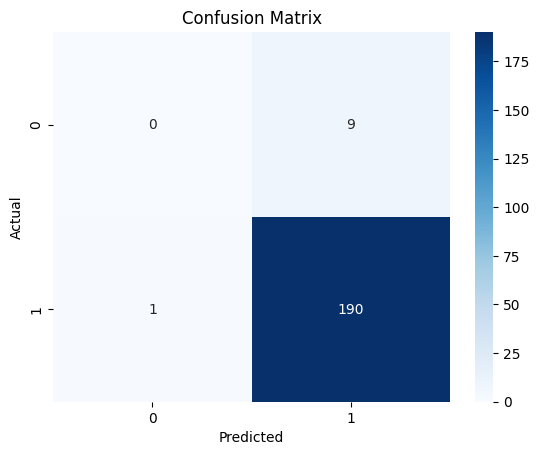

Confusion Matrix:
 [[  0   9]
 [  1 190]]


In [15]:
#train the model using logistic regression
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred_proba = model.predict_proba(x_test)[:, 1]
# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Confusion Matrix:\n", conf_matrix)

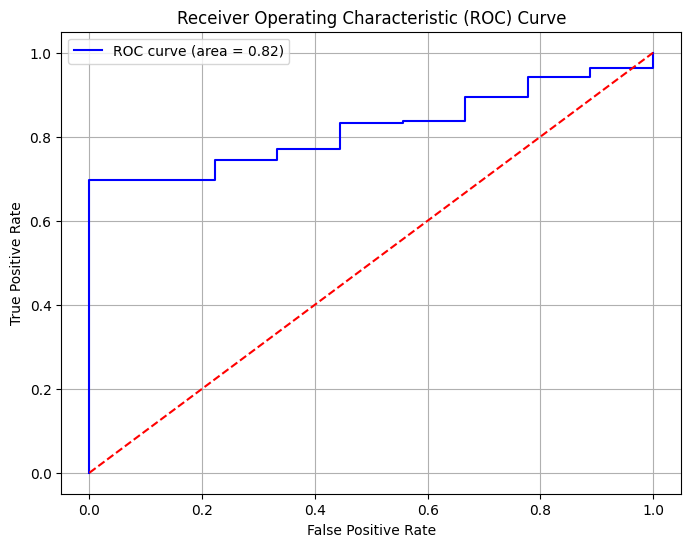

In [16]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')     
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

## Apply lasso Ridge & Elastic Net Regularization Techniques on regreeion Models

In [17]:
# import requirement libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
# Load the dataset
data = pd.read_csv(r"C:\data-Scientist\sample_experience_salary_age.csv")
df = pd.DataFrame(data)
df.head()

,experience,salary,age
0,6,493231,31
1,19,902168,40
2,14,923544,36
3,10,634020,28
4,7,557552,26


In [20]:
x = df[['experience', 'age']]
y = df['salary']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
# Linear Regression Model
model = LogisticRegression()
model.fit(x_train, y_train)
pred_model = model.predict(x_test)
print("Linear Regression Model Results:")
print("Mean Squared Error:", mean_squared_error(y_test, pred_model))
print("R^2 Score:", r2_score(y_test, pred_model))

Linear Regression Model Results:
Mean Squared Error: 80134652571.04
R^2 Score: 0.5904068290017196


In [22]:
# Lasso Regression Model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(x_train, y_train)
pred_lasso = lasso_model.predict(x_test)
print("\nLasso Regression Model Results:")
print("Mean Squared Error:", mean_squared_error(y_test, pred_lasso))
print("R^2 Score:", r2_score(y_test, pred_lasso))




Lasso Regression Model Results:
Mean Squared Error: 26800552600.249012
R^2 Score: 0.8630140273671154


In [23]:
# Ridge Regression Model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train, y_train)
pred_ridge = ridge_model.predict(x_test)
print("\nRidge Regression Model Results:")
print("Mean Squared Error:", mean_squared_error(y_test, pred_ridge))
print("R^2 Score:", r2_score(y_test, pred_ridge))



Ridge Regression Model Results:
Mean Squared Error: 26800571548.631855
R^2 Score: 0.8630139305160283


In [24]:
# Elastic Net Regression Model
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net_model.fit(x_train, y_train)
pred_elastic_net = elastic_net_model.predict(x_test)
print("\nElastic Net Regression Model Results:")
print("Mean Squared Error:", mean_squared_error(y_test, pred_elastic_net))
print("R^2 Score:", r2_score(y_test, pred_elastic_net))


Elastic Net Regression Model Results:
Mean Squared Error: 26809207692.71282
R^2 Score: 0.8629697884934971


## Build a decision tree model and tune hyperparameter GridsearchCV

In [25]:
#import requirement libraries
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Load the dataset
iris = load_iris()
x = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [26]:
# build a decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
# Fit the model
dt_model.fit(X_train, y_train)
# Predict using the model
y_pred = dt_model.predict(X_test)
print("Initial Accuracy:", accuracy_score(y_test, y_pred))

Initial Accuracy: 1.0


In [27]:
# hyperparameter tuning using GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [28]:
# best model evaluation
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))
# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred_best))

Best Model Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Implement randomforest ,AdaBoosting ,Gradient Boosting ,XGBoosting & LightGBM models:-

In [29]:
# import requirement libraries
%pip install xgboost lightgbm
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb
import lightgbm as lgb

  Using cached xgboost-3.0.2-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached xgboost-3.0.2-py3-none-win_amd64.whl (150.0 MB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)

   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------

In [30]:
# load the dataset
iris = load_iris()
x = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [31]:
# Train Models & Collect Results
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42)
}
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    print(f"{model_name} Accuracy: {accuracy}")
    print(f"{model_name} Classification Report:\n{results[model_name]['classification_report']}")
    print(f"{model_name} Confusion Matrix:\n{results[model_name]['confusion_matrix']}\n")

Random Forest Accuracy: 1.0
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Random Forest Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Gradient Boosting Accuracy: 1.0
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Gradient Boosting Confusion Ma

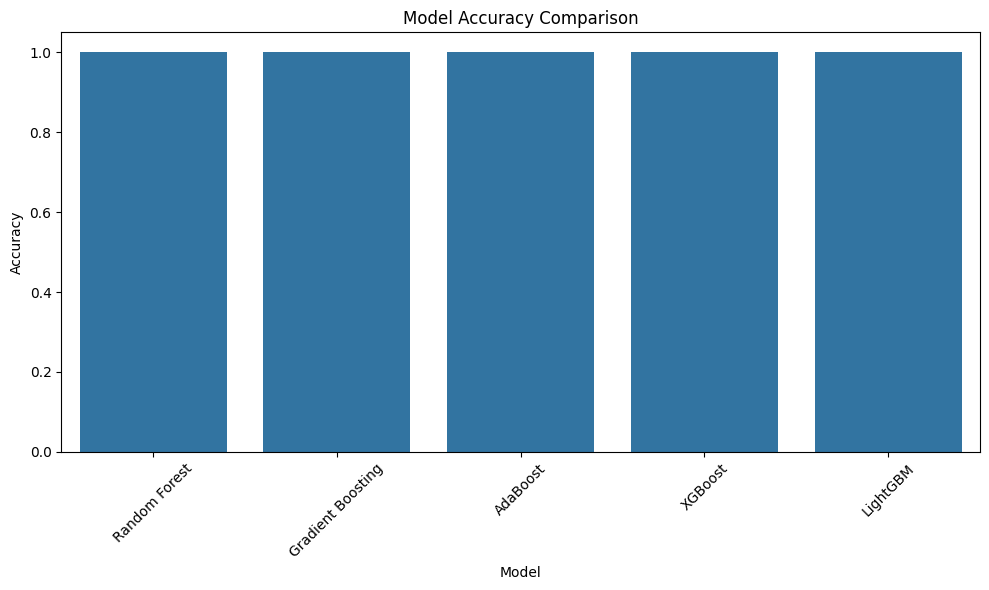

In [32]:
# Compare model
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=[res['accuracy'] for res in results.values()])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Apply Cross validation & k-Flok Tech to evaluate model performance

In [33]:
# import requirement libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split , cross_val_score , KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [34]:
# Load the dataset
iris =load_iris()
x = iris.data
y = iris.target

In [35]:
# Apply Cross -Validation 
model = DecisionTreeClassifier(random_state=42)
Scores = cross_val_score(model,x,y,cv = 5,scoring="accuracy")
print("Cross-Validation Scores:", Scores)
print("Mean Cross-Validation Score:", np.mean(Scores))
print("Standard Deviation of Cross-Validation Scores:", np.std(Scores))

Cross-Validation Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Mean Cross-Validation Score: 0.9533333333333334
Standard Deviation of Cross-Validation Scores: 0.03399346342395189


In [37]:
# use K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = []
for train_index, test_index in kf.split(x):
    X_train_kf, X_test_kf = x[train_index], x[test_index]
    y_train_kf, y_test_kf = y[train_index], y[test_index]
    model.fit(X_train_kf, y_train_kf)
    y_pred_kf = model.predict(X_test_kf)
    kf_scores.append(accuracy_score(y_test_kf, y_pred_kf))
print("K-Fold Cross-Validation Scores:", kf_scores)
print("Mean K-Fold Cross-Validation Score:", np.mean(kf_scores))   


K-Fold Cross-Validation Scores: [1.0, 0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333]
Mean K-Fold Cross-Validation Score: 0.9533333333333335
